In [1]:
import wrds
import pandas as pd

In [2]:
username = "sleeping3316"
db = wrds.Connection(wrds_username="sleeping3316")

Loading library list...
Done


In [3]:
query = """
SELECT 
    date, permno, prc, ret, vol, shrout, bid, ask,
    cfacpr, cfacshr
FROM crsp.dsf
WHERE permno IN (14593, 10107, 14541)   -- 只保留 NVDA, AVGO, INTC
  AND date BETWEEN '2020-01-01' AND '2024-12-31'
"""

df = db.raw_sql(query)


In [4]:
ticker_map = {
    14593: "NVDA",
    10107: "AVGO",
    14541: "INTC",
}
df['ticker'] = df['permno'].map(ticker_map)


df = df.dropna(subset=['ticker'])

df['prc_abs'] = df['prc'].abs()

df['prc_adj'] = df['prc_abs'] / df['cfacpr']

df['shrout_adj'] = df['shrout'] * df['cfacshr'].abs()

df['market_cap_adj'] = df['prc_adj'] * df['shrout_adj']

df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['prc_adj', 'ret'])  
df = df.sort_values(['ticker', 'date'])

df['spread'] = df['ask'] - df['bid']

df.to_csv('cpo_stock_adjusted.csv', index=False)
print(df.head())

        date  permno     prc       ret         vol     shrout        bid  \
0 2020-01-02   10107  160.62  0.018516  22610236.0  7611000.0      160.7   
1 2020-01-03   10107  158.62 -0.012452  21099013.0  7611000.0     158.59   
2 2020-01-06   10107  159.03  0.002585  21156101.0  7611000.0     159.02   
3 2020-01-07   10107  157.58 -0.009118  21844325.0  7611000.0  157.57001   
4 2020-01-08   10107  160.09  0.015928  27722052.0  7611000.0     160.13   

         ask  cfacpr  cfacshr ticker  prc_abs  prc_adj  shrout_adj  \
0     160.73     1.0      1.0   AVGO   160.62   160.62   7611000.0   
1  158.60001     1.0      1.0   AVGO   158.62   158.62   7611000.0   
2     159.03     1.0      1.0   AVGO   159.03   159.03   7611000.0   
3     157.59     1.0      1.0   AVGO   157.58   157.58   7611000.0   
4     160.14     1.0      1.0   AVGO   160.09   160.09   7611000.0   

   market_cap_adj   spread  
0    1222478820.0     0.03  
1    1207256820.0  0.01001  
2    1210377330.0     0.01  
3    1

In [6]:
avg_return = df.groupby('ticker')['ret'].mean()
print("=== Average Daily Return ===")
print(avg_return)

=== Average Daily Return ===
ticker
AVGO    0.001002
INTC    0.000576
NVDA    0.001199
Name: ret, dtype: Float64


In [7]:
volatility = df.groupby('ticker')['ret'].std()
print("\n=== Volatility (Standard Deviation) ===")
print(volatility)


=== Volatility (Standard Deviation) ===
ticker
AVGO     0.01921
INTC      0.0224
NVDA    0.019957
Name: ret, dtype: Float64


In [9]:
mean_mcap = df.groupby('ticker')['market_cap_adj'].mean()
print("\n=== Average Market Cap (Adjusted) ===")
print(mean_mcap)


=== Average Market Cap (Adjusted) ===
ticker
AVGO    2200727844.382987
INTC     252708032.645413
NVDA    2466827663.051413
Name: market_cap_adj, dtype: Float64


In [10]:
mean_spread = df.groupby('ticker')['spread'].mean()
print("\n=== Average Bid-Ask Spread ===")
print(mean_spread)


=== Average Bid-Ask Spread ===
ticker
AVGO    0.060461
INTC    0.020834
NVDA    0.031884
Name: spread, dtype: Float64


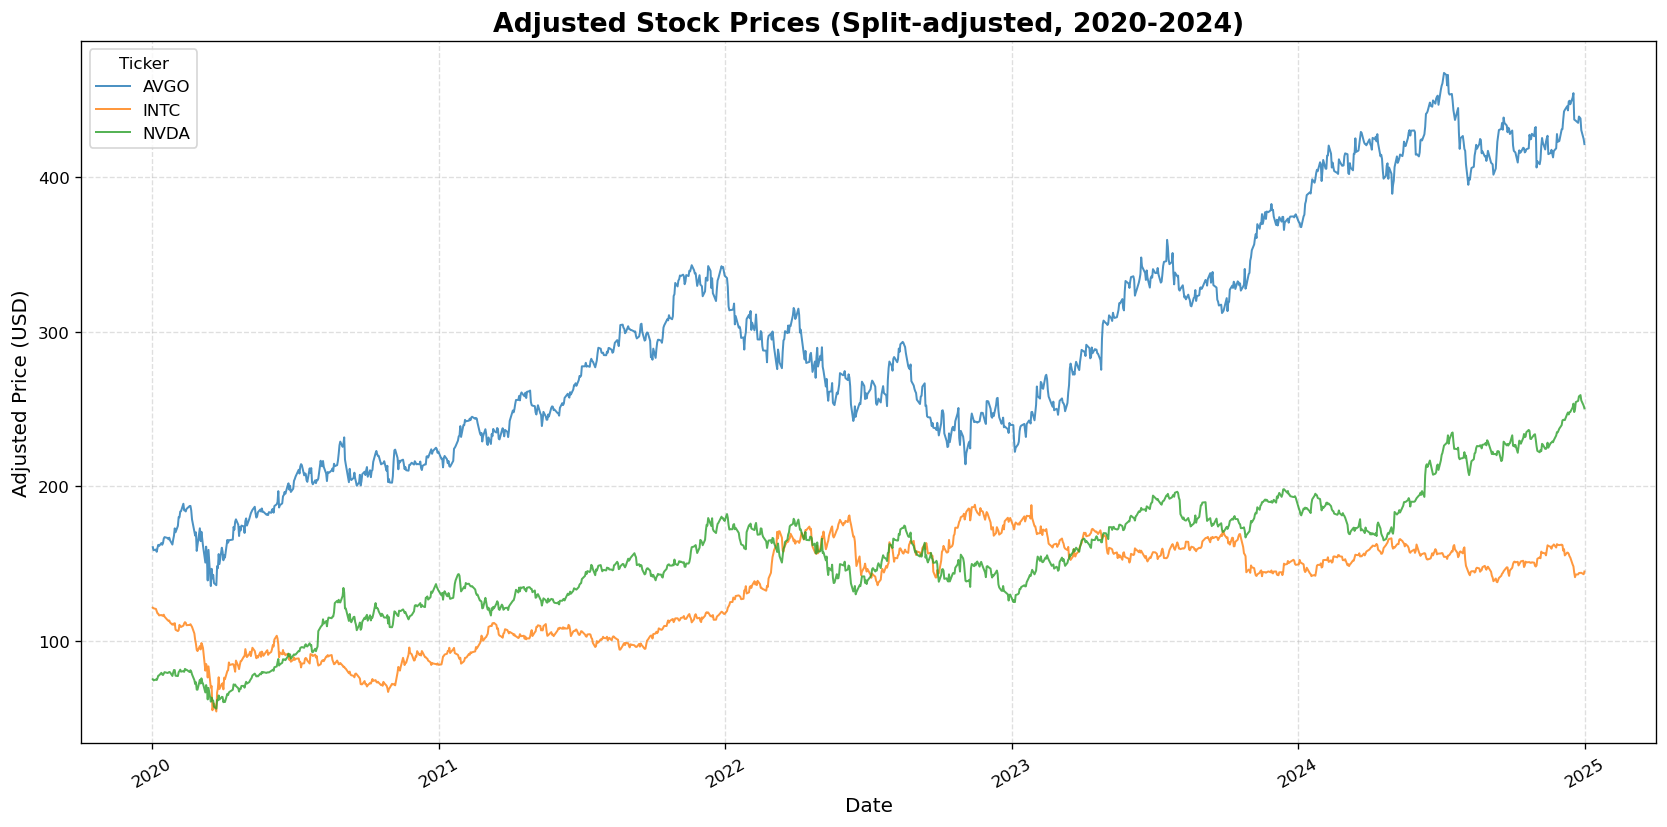

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7), dpi=120)
stock_colors = {'AVGO': '#1f77b4', 'INTC': '#ff7f0e', 'NVDA': '#2ca02c'}

for ticker, color in stock_colors.items():
    subset = df[df['ticker'] == ticker].sort_values('date')
    plt.plot(subset['date'], subset['prc_adj'],
             label=ticker, color=color,
             linewidth=1.2, alpha=0.8)

plt.title("Adjusted Stock Prices (Split-adjusted, 2020-2024)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Adjusted Price (USD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Ticker', fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

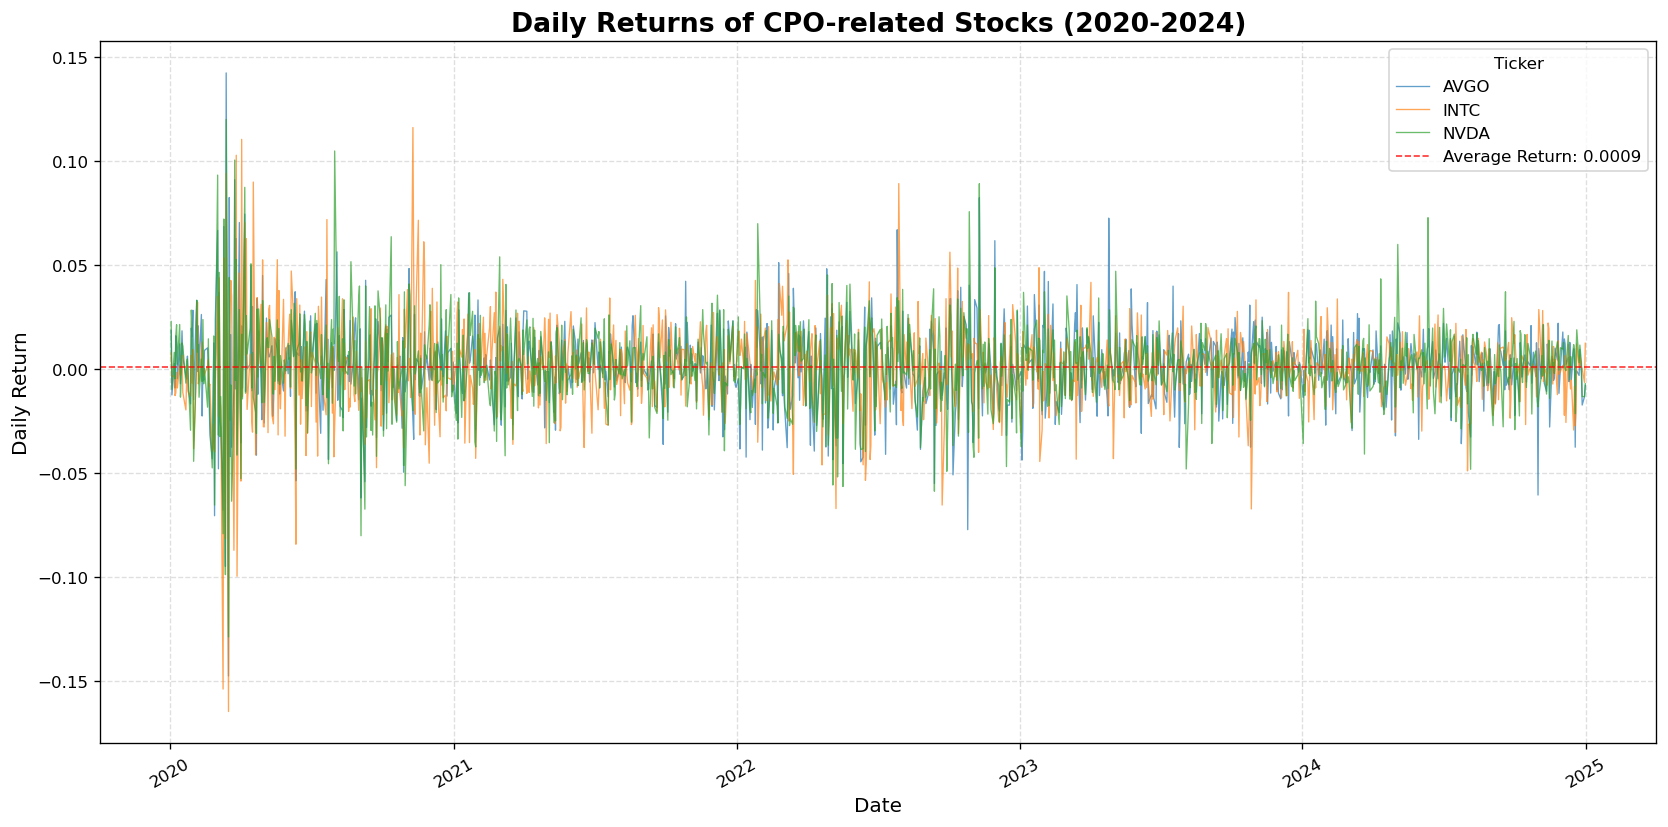

In [15]:
# Filter extreme returns for better visualization
df_clean = df[(df['ret'] >= -0.2) & (df['ret'] <= 0.2)].copy()

plt.figure(figsize=(14, 7), dpi=120)

for ticker, color in stock_colors.items():
    subset = df_clean[df_clean['ticker'] == ticker].sort_values('date')
    plt.plot(subset['date'], subset['ret'],
             label=ticker, color=color,
             markersize=2, linewidth=0.8, alpha=0.7)

plt.title("Daily Returns of CPO-related Stocks (2020-2024)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Return", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Ticker', fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()

# Add average return line
avg_ret = df_clean['ret'].mean()
plt.axhline(y=avg_ret, color='red', linestyle='--', linewidth=1, alpha=0.8,
            label=f'Average Return: {avg_ret:.4f}')
plt.legend(title='Ticker')
plt.show()